In [76]:
#!/usr/bin/env python3
import os
import sys
import pandas as pd
import numpy as np
from scipy.stats import ecdf
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis_k_factor import KFactorAnalyzer


In [77]:
path = "/workspaces/Remodelacao_mestrado/analysis_outputs/Fisica_Atmosferica/2026-01-28_17-05-32_Teste_kt_kd/tabela.csv"
df = pd.read_csv(path, index_col = 0)

df.index = pd.to_datetime(df.index)

In [78]:
# Supondo que seu dataframe se chame 'df'
# E as colunas sejam: 'kt_real', 'kt_pred', 'kd_real', 'kd_pred'

def get_ecdf_df(data, column_name):
    # Calcula a ECDF
    res = ecdf(data)
    
    # Retorna um DataFrame com os valores e suas respectivas probabilidades
    return pd.DataFrame({
        'valor': res.cdf.quantiles,
        'cdf': res.cdf.probabilities,
        'variavel': column_name
    })

# Lista das colunas que você quer processar
colunas = ['kt_real', 'kt_pred', 'kd_real', 'kd_pred']

# Lista para armazenar os mini-dataframes de cada coluna
dfs_ecdf = []

for col in colunas:
    # Remove NaNs para evitar erro no cálculo da ECDF
    dados_limpos = df[col].dropna()
    df_temp = get_ecdf_df(dados_limpos, col)
    dfs_ecdf.append(df_temp)

# Une tudo em um único dataframe
df_final_ecdf = pd.concat(dfs_ecdf, ignore_index=True)

# Exibe as primeiras linhas do resultado
print(df_final_ecdf.head())

      valor       cdf variavel
0  0.040417  0.000317  kt_real
1  0.054608  0.000634  kt_real
2  0.056127  0.000951  kt_real
3  0.061266  0.001268  kt_real
4  0.062079  0.001585  kt_real


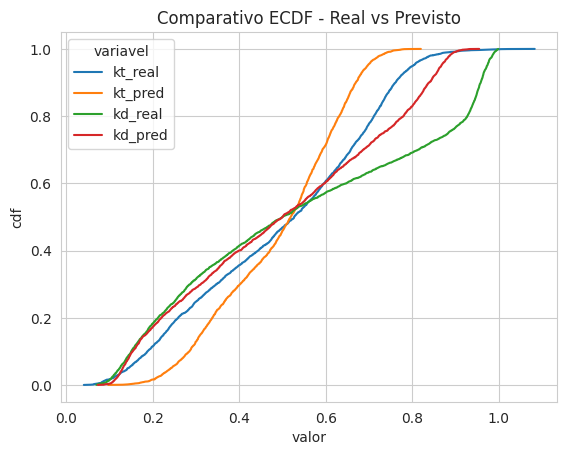

In [79]:
sns.lineplot(data=df_final_ecdf, x='valor', y='cdf', hue='variavel')
plt.title('Comparativo ECDF - Real vs Previsto')
plt.show()

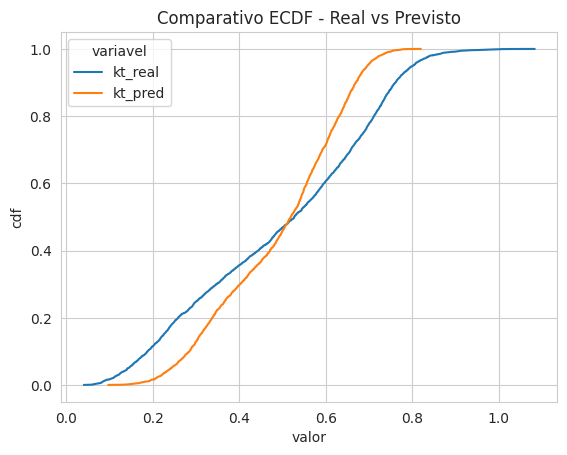

In [80]:
x = df_final_ecdf[(df_final_ecdf['variavel'] == 'kt_real') | (df_final_ecdf['variavel'] == 'kt_pred')]

sns.lineplot(data=x, x='valor', y='cdf', hue='variavel')
plt.title('Comparativo ECDF - Real vs Previsto')
plt.show()

In [81]:
def quantile_mapping(obs, mod):
    """
    Realiza o Quantile Mapping para corrigir o viés de 'mod' usando 'obs' como referência.
    """
    # Remove NaNs para o cálculo das distribuições
    obs_clean = obs.dropna().values
    mod_clean = mod.dropna().values
    
    # 1. Ordenar os dados para criar as distribuições empíricas
    obs_sorted = np.sort(obs_clean)
    mod_sorted = np.sort(mod_clean)
    
    # 2. Criar o eixo de probabilidades (0 a 1)
    prob_obs = np.linspace(0, 1, len(obs_sorted))
    prob_mod = np.linspace(0, 1, len(mod_sorted))
    
    # 3. Encontrar o percentil de cada valor original do modelo
    # Fazemos uma interpolação: dado um valor x, qual sua probabilidade P?
    percentis_mod = np.interp(mod, mod_sorted, prob_mod)
    
    # 4. Encontrar o valor correspondente na distribuição real para esse percentil
    # Inversa: dada uma probabilidade P, qual o valor x na distribuição real?
    mod_corrigido = np.interp(percentis_mod, prob_obs, obs_sorted)
    
    return mod_corrigido

# Aplicando ao seu DataFrame 'df'
df['kt_pred_corr'] = quantile_mapping(df['kt_real'], df['kt_pred'])
df['kd_pred_corr'] = quantile_mapping(df['kd_real'], df['kd_pred'])

# Visualizando o resultado
print(df[['kt_real', 'kt_pred', 'kt_pred_corr']].head())

                            kt_real   kt_pred  kt_pred_corr
Date_Time                                                  
2022-01-02 07:00:00-03:00  0.124534  0.329745      0.247358
2022-01-02 08:00:00-03:00  0.228168  0.271885      0.173450
2022-01-02 09:00:00-03:00  0.504425  0.339855      0.261499
2022-01-02 10:00:00-03:00  0.460698  0.538273      0.558330
2022-01-02 11:00:00-03:00  0.481169  0.497481      0.485941


In [82]:
def get_ecdf_df(data, column_name):
    # Calcula a ECDF
    res = ecdf(data)
    
    # Retorna um DataFrame com os valores e suas respectivas probabilidades
    return pd.DataFrame({
        'valor': res.cdf.quantiles,
        'cdf': res.cdf.probabilities,
        'variavel': column_name
    })

# Lista das colunas que você quer processar
colunas = ['kt_real', 'kt_pred', 'kt_pred_corr']

# Lista para armazenar os mini-dataframes de cada coluna
dfs_ecdf = []

for col in colunas:
    # Remove NaNs para evitar erro no cálculo da ECDF
    dados_limpos = df[col].dropna()
    df_temp = get_ecdf_df(dados_limpos, col)
    dfs_ecdf.append(df_temp)

# Une tudo em um único dataframe
df_final_ecdf = pd.concat(dfs_ecdf, ignore_index=True)

# Exibe as primeiras linhas do resultado
print(df_final_ecdf.head())

      valor       cdf variavel
0  0.040417  0.000317  kt_real
1  0.054608  0.000634  kt_real
2  0.056127  0.000951  kt_real
3  0.061266  0.001268  kt_real
4  0.062079  0.001585  kt_real


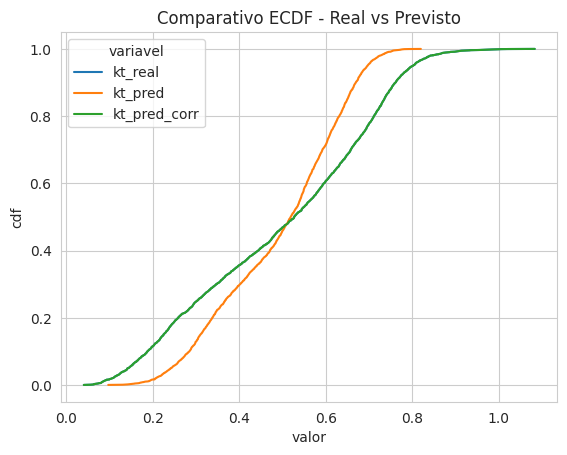

In [83]:
sns.lineplot(data=df_final_ecdf, x='valor', y='cdf', hue='variavel')
plt.title('Comparativo ECDF - Real vs Previsto')
plt.show()

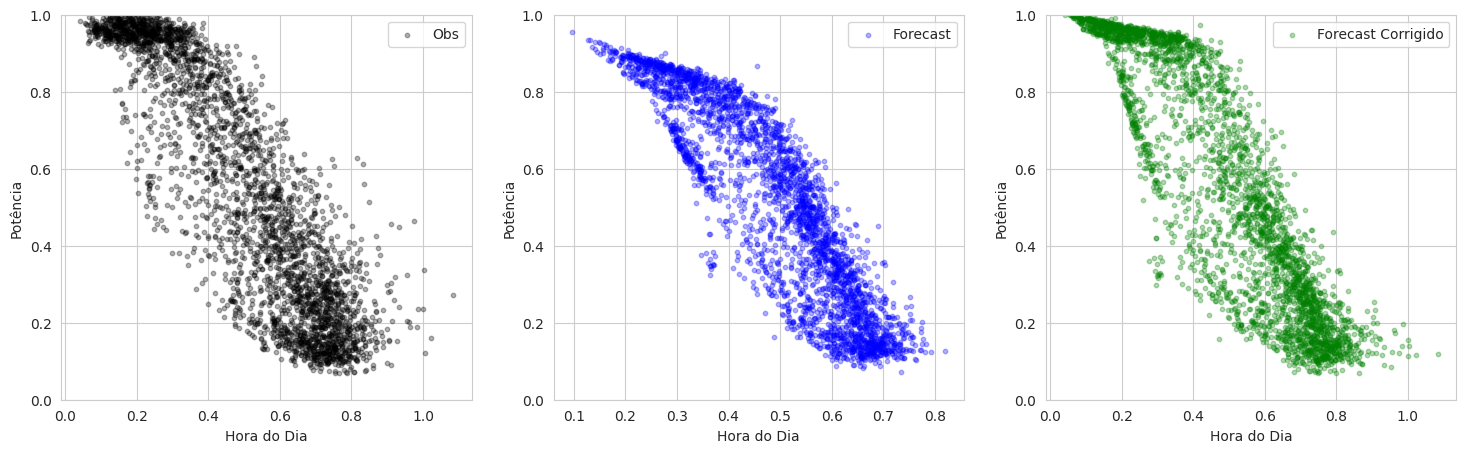

In [84]:
fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(1, 3, 1)

ax1.scatter(df['kt_real'], df['kd_real'], color='black', alpha=0.3, s=10, label='Obs')
#ax1.set_title(f"Dados Originais (Transiente)\n{target_date}")
ax1.set_xlabel("Hora do Dia")
ax1.set_ylabel("Potência")
ax1.set_ylim(0, 1)
ax1.legend()


ax2 = fig.add_subplot(1, 3, 2)

ax2.scatter(df['kt_pred'], df['kd_pred'], color='blue', alpha=0.3, s=10, label='Forecast')
#ax1.set_title(f"Dados Originais (Transiente)\n{target_date}")
ax2.set_xlabel("Hora do Dia")
ax2.set_ylabel("Potência")
ax2.set_ylim(0, 1)
ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)

ax3.scatter(df['kt_pred_corr'], df['kd_pred_corr'], color='green', alpha=0.3, s=10, label='Forecast Corrigido')
#ax1.set_title(f"Dados Originais (Transiente)\n{target_date}")
ax3.set_xlabel("Hora do Dia")
ax3.set_ylabel("Potência")
ax3.set_ylim(0, 1)
ax3.legend()

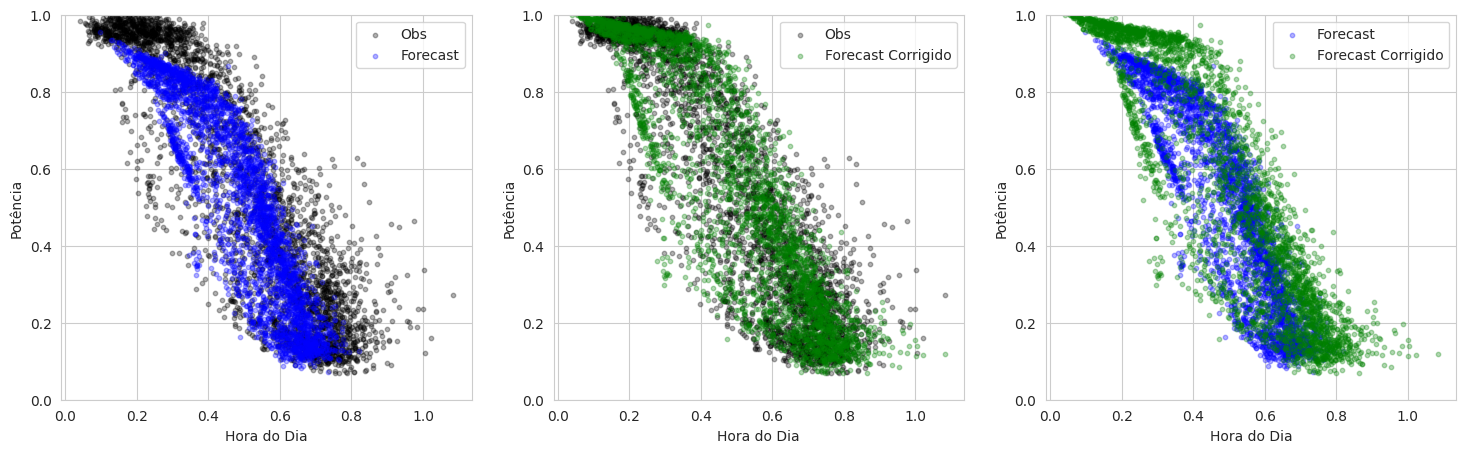

In [85]:
fig = plt.figure(figsize=(18, 5))
ax1 = fig.add_subplot(1, 3, 1)

ax1.scatter(df['kt_real'], df['kd_real'], color='black', alpha=0.3, s=10, label='Obs')
ax1.scatter(df['kt_pred'], df['kd_pred'], color='blue', alpha=0.3, s=10, label='Forecast')
#ax1.set_title(f"Dados Originais (Transiente)\n{target_date}")
ax1.set_xlabel("Hora do Dia")
ax1.set_ylabel("Potência")
ax1.set_ylim(0, 1)
ax1.legend()


ax2 = fig.add_subplot(1, 3, 2)

ax2.scatter(df['kt_real'], df['kd_real'], color='black', alpha=0.3, s=10, label='Obs')
ax2.scatter(df['kt_pred_corr'], df['kd_pred_corr'], color='green', alpha=0.3, s=10, label='Forecast Corrigido')
#ax1.set_title(f"Dados Originais (Transiente)\n{target_date}")
ax2.set_xlabel("Hora do Dia")
ax2.set_ylabel("Potência")
ax2.set_ylim(0, 1)
ax2.legend()

ax3 = fig.add_subplot(1, 3, 3)

ax3.scatter(df['kt_pred'], df['kd_pred'], color='blue', alpha=0.3, s=10, label='Forecast')
ax3.scatter(df['kt_pred_corr'], df['kd_pred_corr'], color='green', alpha=0.3, s=10, label='Forecast Corrigido')
#ax1.set_title(f"Dados Originais (Transiente)\n{target_date}")
ax3.set_xlabel("Hora do Dia")
ax3.set_ylabel("Potência")
ax3.set_ylim(0, 1)
ax3.legend()

In [86]:
# 2. INSTÂNCIA DO NOVO ANALYZER
# Passamos o nome do modelo para criar a pasta organizada
k_analyzer = KFactorAnalyzer(model_name='analise_modelos_sky', output_dir="analysis_outputs")

# 3. CHAMADA DA FIGURA DE 3 PLOTS
# Esta função vai gerar o arquivo .png com os dados de teste
k_analyzer.plot_kt_kd_relationship(df)
k_analyzer.plot_clear_sky_day_analysis(df)
k_analyzer.plot_high_variability_day_analysis(df)
k_analyzer.plot_overcast_day_analysis(df)
k_analyzer.calculate_statistical_metrics(df)
k_analyzer.plot_scatter_validation(df)
k_analyzer.plot_transient_day_analysis(df)

   ☀️ Dia selecionado (10 amostras): 2022-11-17
   ⛈️ Dia selecionado para alta variabilidade: 2022-10-19
   ☁️ Dia selecionado como Encoberto: 2022-11-02
   📊 Calculando métricas estatísticas para: analise_modelos_sky
   ✅ Métricas salvas em: analysis_outputs/Fisica_Atmosferica/analise_modelos_sky/metricas_estatisticas_k.csv
   📈 Gerando matriz de scatter de validação estatística...
   🌦️ Dia Transiente selecionado: 2022-01-03


In [87]:
path = "/workspaces/Remodelacao_mestrado/data/arrudadestroyerdata.csv"
ar = pd.read_csv(path)

path = "/workspaces/Remodelacao_mestrado/data/sp_db.csv"
df_test = pd.read_csv(path)
df_test = df_test.iloc[1:]
df_test['kt_pred_arx'] = ar['0'].values
df_test.set_index('Date_Time', inplace=True)
df_test.index = pd.to_datetime(df_test.index)
df_test.index = df_test.index.tz_convert('America/Sao_Paulo')

<Axes: xlabel='Date_Time'>

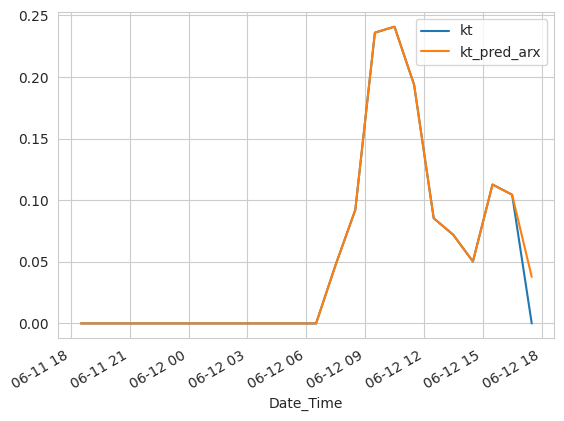

In [88]:
df_test[['kt', 'kt_pred_arx']].head(24).plot()

In [89]:
df.index = pd.to_datetime(df.index)
df.index += pd.Timedelta(minutes=30)
df_ar = pd.merge(df, df_test['kt_pred_arx'], left_index=True, right_index=True, how='inner')
df_ar


,kt_real,kd_real,kt_pred,kd_pred,P_fracao_difusa,P_kt,kt_pred_corr,kd_pred_corr,kt_pred_arx
Date_Time,,,,,,,,,
2022-01-02 10:30:00+00:00,0.124534,0.935801,0.329745,0.649991,0.935014,0.085739,0.247358,0.749502,0.454540
2022-01-02 11:30:00+00:00,0.228168,0.948632,0.271885,0.785848,0.935801,0.124534,0.173450,0.932181,0.425500
2022-01-02 12:30:00+00:00,0.504425,0.694458,0.339855,0.800981,0.948632,0.228168,0.261499,0.939110,0.593100
2022-01-02 13:30:00+00:00,0.460698,0.784860,0.538273,0.573330,0.694458,0.504425,0.558330,0.601283,0.503130
2022-01-02 14:30:00+00:00,0.481169,0.472487,0.497481,0.687639,0.784860,0.460698,0.485941,0.815620,0.605070
...,...,...,...,...,...,...,...,...,...
2022-12-31 17:30:00+00:00,0.347127,0.731183,0.513807,0.601288,0.602813,0.526861,0.517351,0.653607,0.330430
2022-12-31 18:30:00+00:00,0.091774,0.963990,0.418116,0.685929,0.731183,0.347127,0.367555,0.812522,0.250150
2022-12-31 19:30:00+00:00,0.191392,0.966505,0.241105,0.865167,0.963990,0.091774,0.141447,0.972419,0.181860


In [90]:
# 2. INSTÂNCIA DO NOVO ANALYZER
# Passamos o nome do modelo para criar a pasta organizada
k_analyzer = KFactorAnalyzer(model_name='analise_modelos_sky', output_dir="analysis_outputs")

# 3. CHAMADA DA FIGURA DE 3 PLOTS
# Esta função vai gerar o arquivo .png com os dados de teste
k_analyzer.plot_kt_kd_relationship(df_ar)
k_analyzer.plot_clear_sky_day_analysis(df_ar)
k_analyzer.plot_high_variability_day_analysis(df_ar)
k_analyzer.plot_overcast_day_analysis(df_ar)
#k_analyzer.calculate_statistical_metrics(df_ar)
k_analyzer.plot_scatter_validation(df_ar)
k_analyzer.plot_transient_day_analysis(df_ar)

   ☀️ Dia selecionado (10 amostras): 2022-11-17
   ⛈️ Dia selecionado para alta variabilidade: 2022-10-19
   ☁️ Dia selecionado como Encoberto: 2022-11-02
   📈 Gerando matriz de scatter de validação estatística...
   🌦️ Dia Transiente selecionado: 2022-01-03


In [92]:
# Aplicando ao seu DataFrame 'df'
df_ar['kt_pred_arx_corr'] = quantile_mapping(df_ar['kt_real'], df_ar['kt_pred_arx'])
df_ar.head()

,kt_real,kd_real,kt_pred,kd_pred,P_fracao_difusa,P_kt,kt_pred_corr,kd_pred_corr,kt_pred_arx,kt_pred_arx_corr
Date_Time,,,,,,,,,,
2022-01-02 10:30:00+00:00,0.124534,0.935801,0.329745,0.649991,0.935014,0.085739,0.247358,0.749502,0.45454,0.474570
2022-01-02 11:30:00+00:00,0.228168,0.948632,0.271885,0.785848,0.935801,0.124534,0.173450,0.932181,0.42550,0.429287
2022-01-02 12:30:00+00:00,0.504425,0.694458,0.339855,0.800981,0.948632,0.228168,0.261499,0.939110,0.59310,0.633186
2022-01-02 13:30:00+00:00,0.460698,0.784860,0.538273,0.573330,0.694458,0.504425,0.558330,0.601283,0.50313,0.539382
2022-01-02 14:30:00+00:00,0.481169,0.472487,0.497481,0.687639,0.784860,0.460698,0.485941,0.815620,0.60507,0.646315


In [93]:
# 2. INSTÂNCIA DO NOVO ANALYZER
# Passamos o nome do modelo para criar a pasta organizada
k_analyzer = KFactorAnalyzer(model_name='analise_modelos_sky', output_dir="analysis_outputs")

# 3. CHAMADA DA FIGURA DE 3 PLOTS
# Esta função vai gerar o arquivo .png com os dados de teste
k_analyzer.plot_kt_kd_relationship(df_ar)
k_analyzer.plot_clear_sky_day_analysis(df_ar)
k_analyzer.plot_high_variability_day_analysis(df_ar)
k_analyzer.plot_overcast_day_analysis(df_ar)
#k_analyzer.calculate_statistical_metrics(df_ar)
k_analyzer.plot_scatter_validation(df_ar)
k_analyzer.plot_transient_day_analysis(df_ar)

   ☀️ Dia selecionado (10 amostras): 2022-11-17
   ⛈️ Dia selecionado para alta variabilidade: 2022-10-19
   ☁️ Dia selecionado como Encoberto: 2022-11-02
   📈 Gerando matriz de scatter de validação estatística...
   🌦️ Dia Transiente selecionado: 2022-01-03


      valor       cdf variavel
0  0.040417  0.000317  kt_real
1  0.054608  0.000634  kt_real
2  0.056127  0.000951  kt_real
3  0.061266  0.001268  kt_real
4  0.062079  0.001585  kt_real


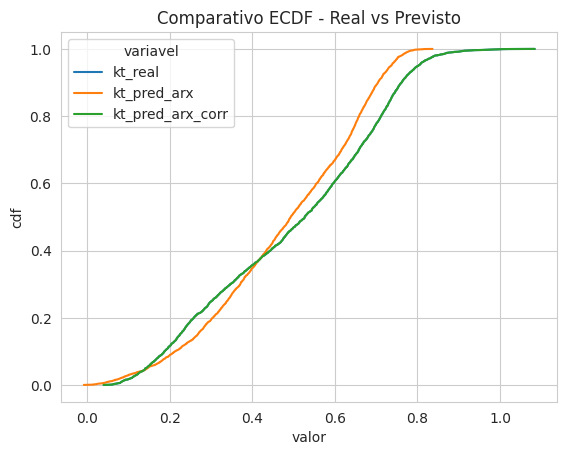

In [94]:
def get_ecdf_df(data, column_name):
    # Calcula a ECDF
    res = ecdf(data)
    
    # Retorna um DataFrame com os valores e suas respectivas probabilidades
    return pd.DataFrame({
        'valor': res.cdf.quantiles,
        'cdf': res.cdf.probabilities,
        'variavel': column_name
    })

# Lista das colunas que você quer processar
colunas = ['kt_real', 'kt_pred_arx', 'kt_pred_arx_corr']

# Lista para armazenar os mini-dataframes de cada coluna
dfs_ecdf = []

for col in colunas:
    # Remove NaNs para evitar erro no cálculo da ECDF
    dados_limpos = df_ar[col].dropna()
    df_temp = get_ecdf_df(dados_limpos, col)
    dfs_ecdf.append(df_temp)

# Une tudo em um único dataframe
df_final_ecdf = pd.concat(dfs_ecdf, ignore_index=True)

# Exibe as primeiras linhas do resultado
print(df_final_ecdf.head())

sns.lineplot(data=df_final_ecdf, x='valor', y='cdf', hue='variavel')
plt.title('Comparativo ECDF - Real vs Previsto')
plt.show()

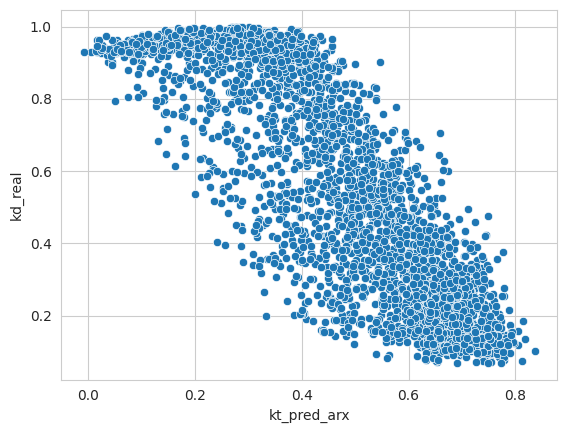

In [98]:
sns.scatterplot(data=df_ar, x='kt_pred_arx', y='kd_real')
#plt.title('Comparativo ECDF - Real vs Previsto')
plt.show()